# Analisis Statistik Preprocessing untuk Skripsi BAB 4.1

Notebook ini membantu Anda mengekstrak statistika deskriptif dan tabel ringkasan yang dibutuhkan untuk menulis **BAB 4.1 (Deskripsi Data dan Hasil Preprocessing)** pada Laporan Tugas Akhir Anda.

Fitur yang dicakup:
1. **Tabel Ringkasan Preprocessing per Wilayah**: Menggabungkan data tile dan persentase validitas citra.
2. **Statistik Deskriptif Sentinel-1 (VV & VH)**: Membandingkan statistik nilai backscatter *raw* (dB) vs *normalized*.
3. **Statistik Deskriptif DEMNAS (Slope & HAND)**: Membandingkan statistik nilai *raw* (derajat/meter) vs *normalized*.
4. **Visualisasi Distribusi**: Membuat plot distribusi (histogram) untuk memperlihatkan efek normalisasi fitur.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from osgeo import gdal

ROOT = Path("..").resolve()
S1_RAW_ROOT = ROOT / "dataset/satelit raw"
PREPROCESSED_ROOT = ROOT / "dataset/features_preprocessed"
FEATURE_SUMMARY_PATH = ROOT / "dataset/feature_preprocessing_summary.csv"
TILE_SUMMARY_PATH = ROOT / "dataset/preprocessing_summary.csv"

print(f"ROOT Workspace: {ROOT}")

ROOT Workspace: /home/nozomi/Productive/skripsi


## 1. Tabel Ringkasan Preprocessing per Wilayah

Selanjutnya kita akan memuat file summary yang dihasilkan pipeline dan menyajikannya dalam satu tabel gabungan yang rapi.

In [2]:
df_features = pd.read_csv(FEATURE_SUMMARY_PATH)
df_tiles = pd.read_csv(TILE_SUMMARY_PATH)

# Gabungkan tabel berdasarkan wilayah
df_combined = pd.merge(df_tiles, df_features, on="region", suffixes=("_tile", "_feat"))

# Rapikan nama kolom dan urutan untuk tabel skripsi
df_formatted = df_combined[[
    "region", "split", "tile_count", "positive_tile_count", "background_tile_count", 
    "s2_valid_pct", "feature_valid_pct", "label_valid_pct", "flood_pixels_tile"
]].copy()

df_formatted.columns = [
    "Wilayah", "Split", "Total Tile", "Tile Positif", "Tile Background", 
    "S2 Valid (%)", "Feature Valid (%)", "Label Valid (%)", "Piksel Banjir"
]

df_formatted = df_formatted.sort_values(by="Wilayah").reset_index(drop=True)
df_formatted

,Wilayah,Split,Total Tile,Tile Positif,Tile Background,S2 Valid (%),Feature Valid (%),Label Valid (%),Piksel Banjir
0,Aceh_Besar,cv,518,315,203,28.447850,35.913186,36.648360,5429056
1,Aceh_Tamiang,cv,465,328,137,0.000386,49.680719,50.216387,4578520
2,Aceh_Timur,cv,1063,543,520,28.764821,52.249722,52.784127,26605176
3,Aceh_Utara,test,493,332,161,45.582018,56.372950,57.301252,22122708
4,Agam,cv,278,139,139,0.000000,51.594569,52.035229,1257081
5,Banda_Aceh,cv,16,16,0,37.536924,42.076136,46.060401,326952
6,Bireuen,cv,303,186,117,55.922736,62.693778,63.241835,3827030
7,Langsa,cv,41,37,4,0.000000,52.017482,53.917292,933776
8,Pasaman_Barat,cv,522,261,261,0.001642,47.087026,47.461440,1462154
9,Pidie,cv,572,286,286,36.817950,38.326207,38.621073,9351866


## 2. Statistik Deskriptif Sentinel-1 (Raw dB vs Normalized)

Fungsi berikut akan membaca citra S1 raw (sebelum clip) dan membandingkannya dengan nilai hasil normalisasi.

In [3]:
def calculate_raster_stats(raster_path, band_idx=1, ignore_nodata=None, nodata_val=None):
    ds = gdal.Open(str(raster_path), gdal.GA_ReadOnly)
    band = ds.GetRasterBand(band_idx)
    arr = band.ReadAsArray().astype(np.float32)
    ds = None
    
    mask = np.isfinite(arr)
    if ignore_nodata and nodata_val is not None:
        mask = mask & (arr != nodata_val)
    
    valid_data = arr[mask]
    if len(valid_data) == 0:
        return 0.0, 0.0, 0.0, 0.0, 0.0
    return {
        "Min": float(np.min(valid_data)),
        "Max": float(np.max(valid_data)),
        "Mean": float(np.mean(valid_data)),
        "Std Dev": float(np.std(valid_data)),
        "Median": float(np.median(valid_data))
    }

# Mari kita hitung statistik raw vs normalized untuk wilayah uji: Aceh Utara
region_raw_dir = S1_RAW_ROOT / "Aceh Utara"
s1_raw_file = list(region_raw_dir.glob("S1_*.tif"))[0]

region_preprocessed_dir = PREPROCESSED_ROOT / "Aceh_Utara"
vv_norm_file = region_preprocessed_dir / "vv_norm.tif"
vh_norm_file = region_preprocessed_dir / "vh_norm.tif"

s1_stats = []

# VV Raw
stats_vv_raw = calculate_raster_stats(s1_raw_file, 1)
stats_vv_raw.update({"Wilayah": "Aceh Utara", "Channel": "VV", "Status": "Raw (dB)"})
s1_stats.append(stats_vv_raw)

# VV Normalized
stats_vv_norm = calculate_raster_stats(vv_norm_file, 1)
stats_vv_norm.update({"Wilayah": "Aceh Utara", "Channel": "VV", "Status": "Normalized"})
s1_stats.append(stats_vv_norm)

# VH Raw
stats_vh_raw = calculate_raster_stats(s1_raw_file, 2)
stats_vh_raw.update({"Wilayah": "Aceh Utara", "Channel": "VH", "Status": "Raw (dB)"})
s1_stats.append(stats_vh_raw)

# VH Normalized
stats_vh_norm = calculate_raster_stats(vh_norm_file, 1)
stats_vh_norm.update({"Wilayah": "Aceh Utara", "Channel": "VH", "Status": "Normalized"})
s1_stats.append(stats_vh_norm)

pd.DataFrame(s1_stats)[["Wilayah", "Channel", "Status", "Min", "Max", "Mean", "Std Dev", "Median"]]

/usr/lib/python3.14/site-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


,Wilayah,Channel,Status,Min,Max,Mean,Std Dev,Median
0,Aceh Utara,VV,Raw (dB),-56.221886,27.506824,-10.224293,6.216154,-8.515324
1,Aceh Utara,VV,Normalized,0.000000,1.000000,0.378625,0.360093,0.429147
2,Aceh Utara,VH,Raw (dB),-59.432346,21.409990,-16.842436,6.203587,-15.139299
3,Aceh Utara,VH,Normalized,0.000000,1.000000,0.256969,0.258790,0.210424


## 3. Statistik Deskriptif DEMNAS (Slope & HAND)

Perhitungan statistik deskriptif untuk data topografi Slope (dalam derajat) dan HAND (dalam meter) beserta nilai setelah dinormalisasi.

In [4]:
slope_raw_file = region_preprocessed_dir / "slope_degrees.tif"
slope_norm_file = region_preprocessed_dir / "slope_norm.tif"
hand_raw_file = region_preprocessed_dir / "hand_meters.tif"
hand_norm_file = region_preprocessed_dir / "hand_norm.tif"

demnas_stats = []

# Slope Raw
stats_slope_raw = calculate_raster_stats(slope_raw_file, 1, ignore_nodata=True, nodata_val=-9999.0)
stats_slope_raw.update({"Wilayah": "Aceh Utara", "Fitur": "Slope", "Satuan/Status": "Derajat (Raw)"})
demnas_stats.append(stats_slope_raw)

# Slope Normalized
stats_slope_norm = calculate_raster_stats(slope_norm_file, 1)
stats_slope_norm.update({"Wilayah": "Aceh Utara", "Fitur": "Slope", "Satuan/Status": "Normalized"})
demnas_stats.append(stats_slope_norm)

# HAND Raw
stats_hand_raw = calculate_raster_stats(hand_raw_file, 1, ignore_nodata=True, nodata_val=-32767)
stats_hand_raw.update({"Wilayah": "Aceh Utara", "Fitur": "HAND", "Satuan/Status": "Meter (Raw)"})
demnas_stats.append(stats_hand_raw)

# HAND Normalized
stats_hand_norm = calculate_raster_stats(hand_norm_file, 1)
stats_hand_norm.update({"Wilayah": "Aceh Utara", "Fitur": "HAND", "Satuan/Status": "Normalized"})
demnas_stats.append(stats_hand_norm)

pd.DataFrame(demnas_stats)[["Wilayah", "Fitur", "Satuan/Status", "Min", "Max", "Mean", "Std Dev", "Median"]]

,Wilayah,Fitur,Satuan/Status,Min,Max,Mean,Std Dev,Median
0,Aceh Utara,Slope,Derajat (Raw),-9999.0,60.674156,-4265.635254,4949.150391,0.394328
1,Aceh Utara,Slope,Normalized,0.0,1.000000,0.083548,0.133924,0.008763
2,Aceh Utara,HAND,Meter (Raw),0.0,930.841492,43.437077,82.442772,16.960861
3,Aceh Utara,HAND,Normalized,0.0,1.000000,0.262259,0.351128,0.096961


## 4. Statistik Deskriptif Sentinel-2 (HSV)

Perhitungan statistik deskriptif global untuk data optis Sentinel-2 hasil transformasi ruang warna HSV (Hue, Saturation, Value) di seluruh 11 wilayah studi, baik untuk piksel valid saja maupun seluruh piksel.

In [5]:
total_pixels = 0
total_valid_pixels = 0

sum_h, sum_s, sum_v = 0.0, 0.0, 0.0
sq_sum_h, sq_sum_s, sq_sum_v = 0.0, 0.0, 0.0
min_h, min_s, min_v = 999.0, 999.0, 999.0
max_h, max_s, max_v = -999.0, -999.0, -999.0

sum_h_all, sum_s_all, sum_v_all = 0.0, 0.0, 0.0
sq_sum_h_all, sq_sum_s_all, sq_sum_v_all = 0.0, 0.0, 0.0
min_h_all, min_s_all, min_v_all = 999.0, 999.0, 999.0
max_h_all, max_s_all, max_v_all = -999.0, -999.0, -999.0

sampled_valid_h = []
sampled_valid_s = []
sampled_valid_v = []

regions = [
    'Aceh_Besar', 'Aceh_Tamiang', 'Aceh_Timur', 'Aceh_Utara', 'Agam',
    'Banda_Aceh', 'Bireuen', 'Langsa', 'Pasaman_Barat', 'Pidie', 'Pidie_Jaya'
]

for r in regions:
    r_dir = PREPROCESSED_ROOT / r
    ds_mask = gdal.Open(str(r_dir / 's2_valid_mask.tif'))
    mask = ds_mask.GetRasterBand(1).ReadAsArray().astype(bool)
    
    ds_h = gdal.Open(str(r_dir / 'hue.tif'))
    h = ds_h.GetRasterBand(1).ReadAsArray().astype(np.float32)
    
    ds_s = gdal.Open(str(r_dir / 'saturation.tif'))
    s = ds_s.GetRasterBand(1).ReadAsArray().astype(np.float32)
    
    ds_v = gdal.Open(str(r_dir / 'value.tif'))
    v = ds_v.GetRasterBand(1).ReadAsArray().astype(np.float32)
    
    n_pixels = h.size
    total_pixels += n_pixels
    
    h_valid = h[mask]
    s_valid = s[mask]
    v_valid = v[mask]
    
    n_valid = h_valid.size
    total_valid_pixels += n_valid
    
    sum_h_all += float(np.sum(h))
    sum_s_all += float(np.sum(s))
    sum_v_all += float(np.sum(v))
    sq_sum_h_all += float(np.sum(h**2))
    sq_sum_s_all += float(np.sum(s**2))
    sq_sum_v_all += float(np.sum(v**2))
    min_h_all = min(min_h_all, float(np.min(h)))
    min_s_all = min(min_s_all, float(np.min(s)))
    min_v_all = min(min_v_all, float(np.min(v)))
    max_h_all = max(max_h_all, float(np.max(h)))
    max_s_all = max(max_s_all, float(np.max(s)))
    max_v_all = max(max_v_all, float(np.max(v)))
    
    if n_valid > 0:
        sum_h += float(np.sum(h_valid))
        sum_s += float(np.sum(s_valid))
        sum_v += float(np.sum(v_valid))
        sq_sum_h += float(np.sum(h_valid**2))
        sq_sum_s += float(np.sum(s_valid**2))
        sq_sum_v += float(np.sum(v_valid**2))
        min_h = min(min_h, float(np.min(h_valid)))
        min_s = min(min_s, float(np.min(s_valid)))
        min_v = min(min_v, float(np.min(v_valid)))
        max_h = max(max_h, float(np.max(h_valid)))
        max_s = max(max_s, float(np.max(s_valid)))
        max_v = max(max_v, float(np.max(v_valid)))
        
        step = max(1, n_valid // 100000)
        sampled_valid_h.extend(h_valid[::step].tolist())
        sampled_valid_s.extend(s_valid[::step].tolist())
        sampled_valid_v.extend(v_valid[::step].tolist())

mean_h = sum_h / total_valid_pixels
std_h = np.sqrt(sq_sum_h / total_valid_pixels - mean_h**2)
med_h = np.median(sampled_valid_h)

mean_s = sum_s / total_valid_pixels
std_s = np.sqrt(sq_sum_s / total_valid_pixels - mean_s**2)
med_s = np.median(sampled_valid_s)

mean_v = sum_v / total_valid_pixels
std_v = np.sqrt(sq_sum_v / total_valid_pixels - mean_v**2)
med_v = np.median(sampled_valid_v)

mean_h_all = sum_h_all / total_pixels
std_h_all = np.sqrt(sq_sum_h_all / total_pixels - mean_h_all**2)

mean_s_all = sum_s_all / total_pixels
std_s_all = np.sqrt(sq_sum_s_all / total_pixels - mean_s_all**2)

mean_v_all = sum_v_all / total_pixels
std_v_all = np.sqrt(sq_sum_v_all / total_pixels - mean_v_all**2)

s2_stats = [
    {"Fitur": "Hue (H)", "Populasi": "Piksel Valid Saja", "Min": min_h, "Max": max_h, "Mean": mean_h, "Std Dev": std_h, "Median": med_h},
    {"Fitur": "Hue (H)", "Populasi": "Seluruh Piksel", "Min": min_h_all, "Max": max_h_all, "Mean": mean_h_all, "Std Dev": std_h_all, "Median": 0.0},
    {"Fitur": "Saturation (S)", "Populasi": "Piksel Valid Saja", "Min": min_s, "Max": max_s, "Mean": mean_s, "Std Dev": std_s, "Median": med_s},
    {"Fitur": "Saturation (S)", "Populasi": "Seluruh Piksel", "Min": min_s_all, "Max": max_s_all, "Mean": mean_s_all, "Std Dev": std_s_all, "Median": 0.0},
    {"Fitur": "Value (V)", "Populasi": "Piksel Valid Saja", "Min": min_v, "Max": max_v, "Mean": mean_v, "Std Dev": std_v, "Median": med_v},
    {"Fitur": "Value (V)", "Populasi": "Seluruh Piksel", "Min": min_v_all, "Max": max_v_all, "Mean": mean_v_all, "Std Dev": std_v_all, "Median": 0.0}
]

pd.DataFrame(s2_stats)[["Fitur", "Populasi", "Min", "Max", "Mean", "Std Dev", "Median"]]

,Fitur,Populasi,Min,Max,Mean,Std Dev,Median
0,Hue (H),Piksel Valid Saja,0.0000,0.99988,0.324175,0.069541,0.307651
1,Hue (H),Seluruh Piksel,0.0000,0.99988,0.078952,0.143313,0.000000
2,Saturation (S),Piksel Valid Saja,0.0000,1.00000,0.869968,0.132059,0.912475
3,Saturation (S),Seluruh Piksel,0.0000,1.00000,0.211880,0.379055,0.000000
4,Value (V),Piksel Valid Saja,0.0072,1.00000,0.300428,0.089582,0.292200
5,Value (V),Seluruh Piksel,0.0000,1.00000,0.073169,0.136319,0.000000


## 5. Plot Distribusi Nilai Fitur (Efek Preprocessing)

Visualisasi histogram mempermudah pembahasan bagaimana normalisasi membatasi outliers dan membuat data siap untuk neural network.

Memuat data untuk plotting...
Distributions plot saved to: /home/nozomi/Productive/skripsi/runs/final/preprocessing_distributions.png


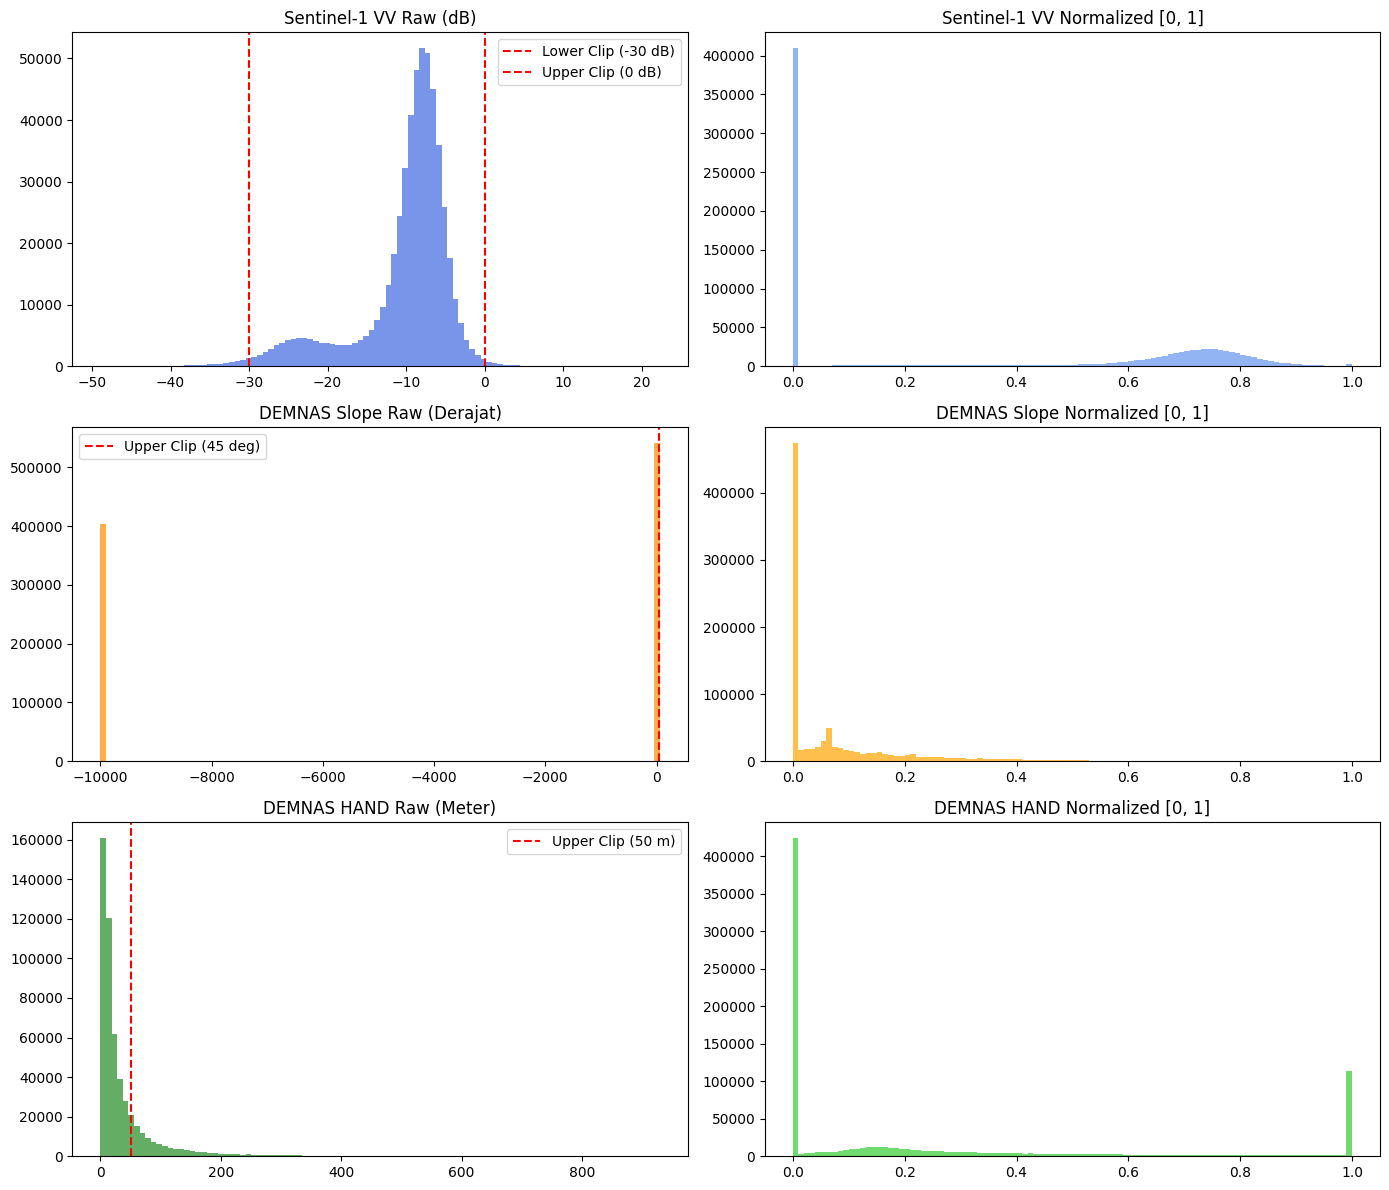

In [6]:
def get_valid_flat_array(raster_path, band_idx=1, nodata_val=None, sample_step=50):
    ds = gdal.Open(str(raster_path), gdal.GA_ReadOnly)
    arr = ds.GetRasterBand(band_idx).ReadAsArray().astype(np.float32)
    ds = None
    mask = np.isfinite(arr)
    if nodata_val is not None:
        mask = mask & (arr != nodata_val)
    return arr[mask][::sample_step] # Downsample agar plotting cepat

print("Memuat data untuk plotting...")
vv_raw_data = get_valid_flat_array(s1_raw_file, 1)
vv_norm_data = get_valid_flat_array(vv_norm_file, 1)
slope_raw_data = get_valid_flat_array(slope_raw_file, 1, -9999.0)
slope_norm_data = get_valid_flat_array(slope_norm_file, 1)
hand_raw_data = get_valid_flat_array(hand_raw_file, 1, -32767)
hand_norm_data = get_valid_flat_array(hand_norm_file, 1)

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# Sentinel-1 VV
axes[0, 0].hist(vv_raw_data, bins=100, color='royalblue', alpha=0.7)
axes[0, 0].set_title("Sentinel-1 VV Raw (dB)")
axes[0, 0].axvline(-30, color='red', linestyle='--', label='Lower Clip (-30 dB)')
axes[0, 0].axvline(0, color='red', linestyle='--', label='Upper Clip (0 dB)')
axes[0, 0].legend()

axes[0, 1].hist(vv_norm_data, bins=100, color='cornflowerblue', alpha=0.7)
axes[0, 1].set_title("Sentinel-1 VV Normalized [0, 1]")

# DEMNAS Slope
axes[1, 0].hist(slope_raw_data, bins=100, color='darkorange', alpha=0.7)
axes[1, 0].set_title("DEMNAS Slope Raw (Derajat)")
axes[1, 0].axvline(45, color='red', linestyle='--', label='Upper Clip (45 deg)')
axes[1, 0].legend()

axes[1, 1].hist(slope_norm_data, bins=100, color='orange', alpha=0.7)
axes[1, 1].set_title("DEMNAS Slope Normalized [0, 1]")

# DEMNAS HAND
axes[2, 0].hist(hand_raw_data, bins=100, color='forestgreen', alpha=0.7)
axes[2, 0].set_title("DEMNAS HAND Raw (Meter)")
axes[2, 0].axvline(50, color='red', linestyle='--', label='Upper Clip (50 m)')
axes[2, 0].legend()

axes[2, 1].hist(hand_norm_data, bins=100, color='limegreen', alpha=0.7)
axes[2, 1].set_title("DEMNAS HAND Normalized [0, 1]")

plt.tight_layout()
output_plot = ROOT / "runs/final/preprocessing_distributions.png"
plt.savefig(output_plot, dpi=300)
print(f"Distributions plot saved to: {output_plot}")
plt.show()

## 6. Visualisasi Spasial 2D Citra Sentinel-1 (Sebelum vs Sesudah Normalisasi)

Bagian ini memvisualisasikan citra Sentinel-1 secara spasial 2D (dengan downsampling agar menghemat memori) untuk memperlihatkan bagaimana efek clipping dan normalisasi secara visual pada citra radar.

Memuat citra spasial Sentinel-1...
Spatial comparison plot saved to: /home/nozomi/Productive/skripsi/runs/final/s1_spatial_comparison.png


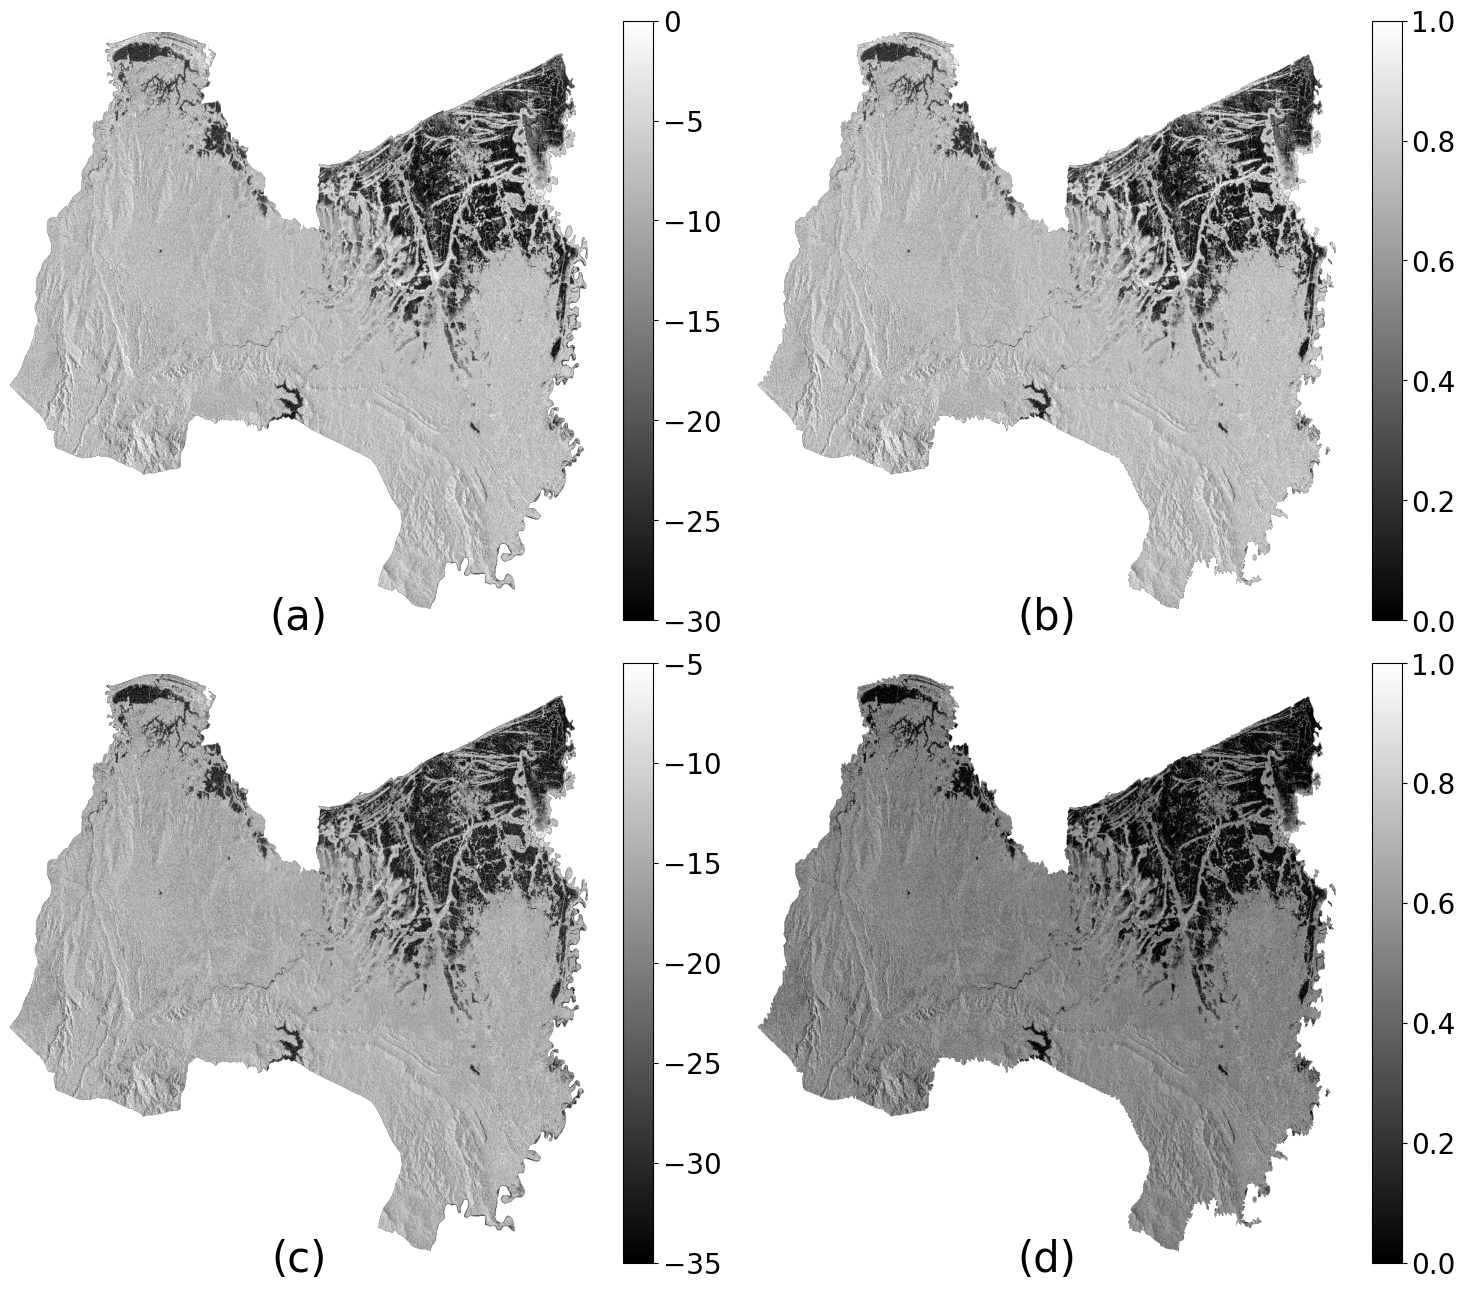

In [7]:
def read_downsampled_raster(raster_path, band_idx=1, target_size=(1000, 1000)):
    ds = gdal.Open(str(raster_path), gdal.GA_ReadOnly)
    band = ds.GetRasterBand(band_idx)
    # Menggunakan buf_xsize dan buf_ysize dari GDAL untuk downsampling cepat
    arr = band.ReadAsArray(buf_xsize=target_size[0], buf_ysize=target_size[1]).astype(np.float32)
    ds = None
    # Bersihkan NaN/Inf untuk keperluan visualisasi
    arr[~np.isfinite(arr)] = np.nan
    return arr

print("Memuat citra spasial Sentinel-1...")
vv_raw_img = read_downsampled_raster(s1_raw_file, 1)
vv_norm_img = read_downsampled_raster(vv_norm_file, 1)
vh_raw_img = read_downsampled_raster(s1_raw_file, 2)
vh_norm_img = read_downsampled_raster(vh_norm_file, 1)

# Membaca mask validitas fitur untuk menyamakan background (set no-data ke NaN)
valid_mask_img = read_downsampled_raster(region_preprocessed_dir / "feature_valid_mask.tif", 1)
vv_norm_img[valid_mask_img == 0] = np.nan
vh_norm_img[valid_mask_img == 0] = np.nan

# Plotting spasial 2D
fig, axes = plt.subplots(2, 2, figsize=(15, 13))

# Row 0: Polarisasi VV
im0 = axes[0, 0].imshow(vv_raw_img, cmap='gray', vmin=-30, vmax=0)
axes[0, 0].set_title("(a)", fontsize=30, y=-0.05)
fig.colorbar(im0, ax=axes[0, 0]).ax.tick_params(labelsize=20)
axes[0, 0].axis('off')

im1 = axes[0, 1].imshow(vv_norm_img, cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title("(b)", fontsize=30, y=-0.05)
fig.colorbar(im1, ax=axes[0, 1]).ax.tick_params(labelsize=20)
axes[0, 1].axis('off')

# Row 1: Polarisasi VH
im2 = axes[1, 0].imshow(vh_raw_img, cmap='gray', vmin=-35, vmax=-5)
axes[1, 0].set_title("(c)", fontsize=30, y=-0.05)
fig.colorbar(im2, ax=axes[1, 0]).ax.tick_params(labelsize=20)
axes[1, 0].axis('off')

im3 = axes[1, 1].imshow(vh_norm_img, cmap='gray', vmin=0, vmax=1)
axes[1, 1].set_title("(d)", fontsize=30, y=-0.05)
fig.colorbar(im3, ax=axes[1, 1]).ax.tick_params(labelsize=20)
axes[1, 1].axis('off')

plt.tight_layout()
output_spatial_plot = ROOT / "runs/final/s1_spatial_comparison.png"
plt.savefig(output_spatial_plot, dpi=300, bbox_inches='tight')
print(f"Spatial comparison plot saved to: {output_spatial_plot}")
plt.show()

## 7. Visualisasi Transformasi Ruang Warna Sentinel-2 (RGB Biasa vs Preprocessed HSV)

Bagian ini memvisualisasikan perbandingan citra Sentinel-2 antara **RGB Biasa (True Color)** dengan hasil **Preprocessing HSV** (hasil rekonstruksi kembali ke ruang warna RGB/Pseudo-RGB setelah masking awan) secara spasial 2D.

Memuat data citra Sentinel-2...
Sentinel-2 HSV comparison plot saved to: /home/nozomi/Productive/skripsi/runs/final/s2_hsv_comparison.png


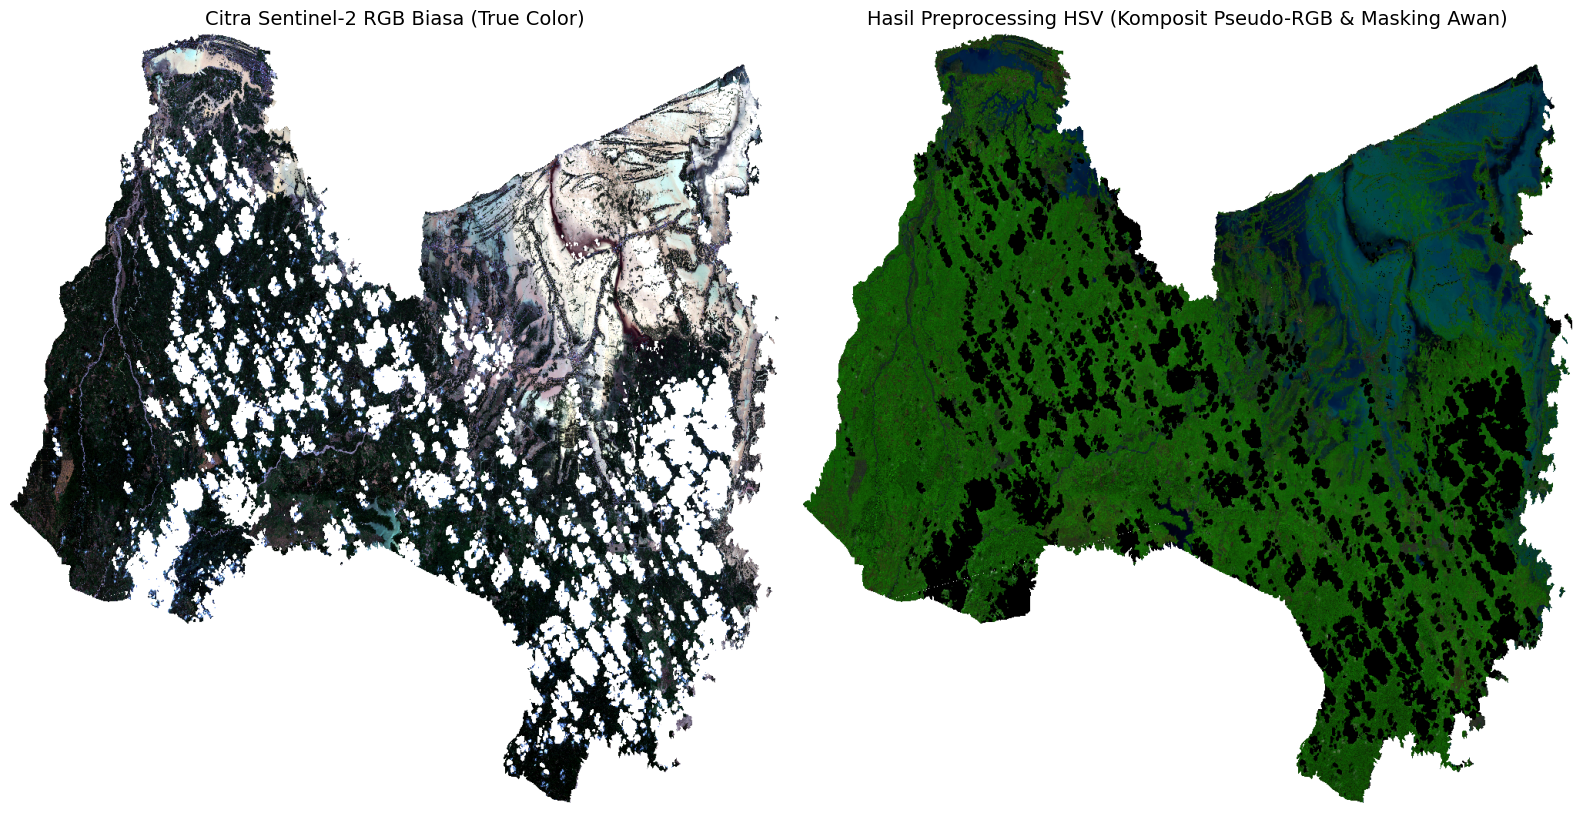

In [8]:
def contrast_stretch(arr, percentiles=(2, 98)):
    """Melakukan linear contrast stretch untuk visualisasi citra penginderaan jauh."""
    p_low, p_high = np.nanpercentile(arr, percentiles)
    if p_high == p_low:
        return np.zeros_like(arr)
    stretched = np.clip((arr - p_low) / (p_high - p_low), 0.0, 1.0)
    return stretched

print("Memuat data citra Sentinel-2...")
s2_raw_file = list((S1_RAW_ROOT / "Aceh Utara").glob("S2_*.tif"))[0]

# Read True Color RGB bands (R=B4, G=B3, B=B2)
r_raw = read_downsampled_raster(s2_raw_file, 3) # Band 4 (Red)
g_raw = read_downsampled_raster(s2_raw_file, 2) # Band 3 (Green)
b_raw = read_downsampled_raster(s2_raw_file, 1) # Band 2 (Blue)

# Read feature valid mask to define the administrative boundary
feature_valid_img = read_downsampled_raster(region_preprocessed_dir / "feature_valid_mask.tif", 1)
boundary_mask = (feature_valid_img == 1)

# Read validity mask of Sentinel-2
s2_valid_img = read_downsampled_raster(region_preprocessed_dir / "s2_valid_mask.tif", 1)

# Contrast stretch True Color RGB bands
r_stretched = contrast_stretch(r_raw)
g_stretched = contrast_stretch(g_raw)
b_stretched = contrast_stretch(b_raw)

true_rgb = np.stack([r_stretched, g_stretched, b_stretched], axis=-1)
# Set background outside the boundary to white (1.0)
true_rgb[~boundary_mask] = 1.0
# Set cloud/shadow pixels (inside boundary but invalid) to white (1.0)
invalid_inside = boundary_mask & (s2_valid_img == 0)
true_rgb[invalid_inside] = 1.0

# Load HSV preprocessed features
hue_img = read_downsampled_raster(region_preprocessed_dir / "hue.tif", 1)
sat_img = read_downsampled_raster(region_preprocessed_dir / "saturation.tif", 1)
val_img = read_downsampled_raster(region_preprocessed_dir / "value.tif", 1)

# Reconstruct HSV to RGB
import matplotlib.colors as colors
hsv_img = np.stack([hue_img, sat_img, val_img], axis=-1)
hsv_rgb = colors.hsv_to_rgb(hsv_img)

# Set background outside the boundary to white (1.0)
hsv_rgb[~boundary_mask] = 1.0
# Set cloud/shadow pixels (inside boundary but invalid) to black (0.0)
hsv_rgb[invalid_inside] = 0.0

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Standard RGB (True Color)
axes[0].imshow(true_rgb)
axes[0].set_title("Citra Sentinel-2 RGB Biasa (True Color)", fontsize=14)
axes[0].axis('off')

# 2. Reconstructed Preprocessed HSV
axes[1].imshow(hsv_rgb)
axes[1].set_title("Hasil Preprocessing HSV (Komposit Pseudo-RGB & Masking Awan)", fontsize=14)
axes[1].axis('off')

plt.tight_layout()
output_s2_plot = ROOT / "runs/final/s2_hsv_comparison.png"
plt.savefig(output_s2_plot, dpi=300, bbox_inches='tight')
print(f"Sentinel-2 HSV comparison plot saved to: {output_s2_plot}")
plt.show()

## 8. Visualisasi Spasial 2D Citra DEMNAS (Sebelum vs Sesudah Preprocessing)

Bagian ini memvisualisasikan data topografi DEMNAS untuk wilayah uji (Aceh Utara), menampilkan fitur kemiringan lereng (**Slope**) dalam derajat dan ketinggian relatif di atas jaringan drainase terdekat (**HAND**) dalam meter, baik sebelum maupun sesudah normalisasi secara spasial 2D.

In [ ]:
print("Memuat data citra DEMNAS...")
slope_raw_img = read_downsampled_raster(slope_raw_file, 1)
slope_norm_img = read_downsampled_raster(slope_norm_file, 1)
hand_raw_img = read_downsampled_raster(hand_raw_file, 1)
hand_norm_img = read_downsampled_raster(hand_norm_file, 1)

# Membaca mask validitas fitur
valid_mask_img = read_downsampled_raster(region_preprocessed_dir / "feature_valid_mask.tif", 1)

# Masking nodata
slope_raw_img[slope_raw_img == -9999.0] = np.nan
hand_raw_img[hand_raw_img == -32767.0] = np.nan

# Masking background
slope_raw_img[valid_mask_img == 0] = np.nan
slope_norm_img[valid_mask_img == 0] = np.nan
hand_raw_img[valid_mask_img == 0] = np.nan
hand_norm_img[valid_mask_img == 0] = np.nan

# Plotting spasial 2D (2x2)
fig, axes = plt.subplots(2, 2, figsize=(15, 13))

# Row 0: Slope
im0 = axes[0, 0].imshow(slope_raw_img, cmap='copper', vmin=0, vmax=45)
axes[0, 0].set_title("(a) DEMNAS Slope Raw (Derajat)", fontsize=16)
fig.colorbar(im0, ax=axes[0, 0], label='Derajat').ax.tick_params(labelsize=14)
axes[0, 0].axis('off')

im1 = axes[0, 1].imshow(slope_norm_img, cmap='copper', vmin=0, vmax=1)
axes[0, 1].set_title("(b) DEMNAS Slope Normalized [0, 1]", fontsize=16)
fig.colorbar(im1, ax=axes[0, 1], label='Skala Normalized').ax.tick_params(labelsize=14)
axes[0, 1].axis('off')

# Row 1: HAND
im2 = axes[1, 0].imshow(hand_raw_img, cmap='Blues', vmin=0, vmax=50)
axes[1, 0].set_title("(c) DEMNAS HAND Raw (Meter)", fontsize=16)
fig.colorbar(im2, ax=axes[1, 0], label='Meter').ax.tick_params(labelsize=14)
axes[1, 0].axis('off')

im3 = axes[1, 1].imshow(hand_norm_img, cmap='Blues', vmin=0, vmax=1)
axes[1, 1].set_title("(d) DEMNAS HAND Normalized [0, 1]", fontsize=16)
fig.colorbar(im3, ax=axes[1, 1], label='Skala Normalized').ax.tick_params(labelsize=14)
axes[1, 1].axis('off')

plt.tight_layout()
output_demnas_plot = ROOT / "runs/final/demnas_spatial_comparison.png"
plt.savefig(output_demnas_plot, dpi=300, bbox_inches='tight')
print(f"DEMNAS spatial comparison plot saved to: {output_demnas_plot}")
plt.show()